In [1]:
%load_ext watermark


In [2]:
import io
import os
import requests


from IPython.display import display
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp

import pylib  # noqa: F401


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-04-01T05:32:29.111661+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot   : 1.4.2
requests  : 2.25.1
seaborn   : 0.13.2
pylib     : 0.0.0
pandas    : 2.2.3
matplotlib: 3.9.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get("NOTEBOOK_NAME", "2026-03-31-benchmark")
teeplot_subdir


'2026-03-31-benchmark'

## Prep Data


In [5]:
resp = requests.get("http://osf.io/download/utv5w", allow_redirects=True)
resp.raise_for_status()
df = pd.read_csv(io.BytesIO(resp.content))
display(df.describe()), display(df.head()), display(df.tail());


,n_leaves,seconds
count,2.910000e+03,1.356000e+03
mean,3.380676e+06,5.240682e+07
std,8.060839e+06,3.538082e+08
min,1.000000e+02,6.562000e-06
25%,1.000000e+03,4.628112e-03
50%,3.000000e+04,1.824170e-01
75%,1.000000e+06,6.095955e+01
max,3.000000e+07,4.804567e+09


,library,n_leaves,operation,seconds,status
0,phyloframe,100,load_newick,0.000611,NaN
1,phyloframe,100,save_newick,0.009734,NaN
2,phyloframe,100,preorder,NaN,NaN
3,phyloframe,100,postorder,0.000048,NaN
4,phyloframe,100,inorder,0.008569,NaN


,library,n_leaves,operation,seconds,status
2905,ete,3000000,newick_gzip_bytes,NaN,UNAVAILABLE
2906,ete,3000000,csv_bytes,NaN,UNAVAILABLE
2907,ete,3000000,csv_gzip_bytes,NaN,UNAVAILABLE
2908,ete,3000000,parquet_bytes,NaN,UNAVAILABLE
2909,ete,3000000,feather_bytes,NaN,UNAVAILABLE


## Example Plot


In [6]:
df["throughput"] = df["n_leaves"] / df["seconds"]


teeplots/2026-03-31-benchmark/col=operation+hue=library+kind=line+viz=relplot+x=tips+y=tips-per-sec+ext=.pdf
teeplots/2026-03-31-benchmark/col=operation+hue=library+kind=line+viz=relplot+x=tips+y=tips-per-sec+ext=.png


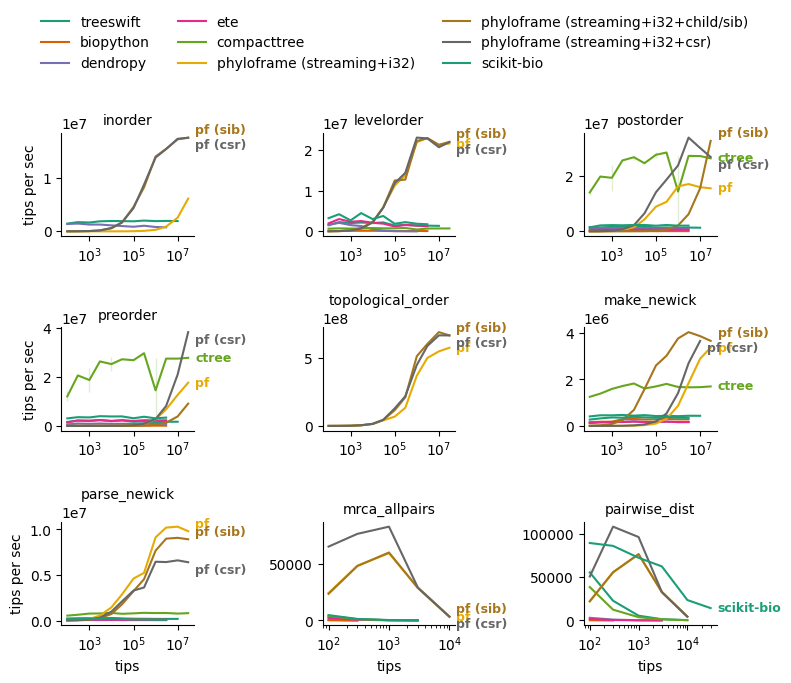

In [7]:
# 1. Extract the filtered data so we can easily reference it for labeling
plot_df = df[
    ~df["operation"].str.contains("bytes")
    & ~df["operation"].str.contains("save")
    & ~df["operation"].str.contains("load")
    & (df["library"] != "phyloframe")
    & (df["library"] != "phyloframe (in-memory)")
].copy()
plot_df["tips"] = plot_df["n_leaves"]
plot_df["tips per sec"] = plot_df["throughput"]

unique_libs = plot_df["library"].unique()
palette = sns.color_palette("Dark2", n_colors=len(unique_libs))
with tp.teed(
    sns.relplot,
    data=plot_df,
    x="tips",
    y="tips per sec",
    hue="library",
    col="operation",
    col_order=[
        "inorder",
        "levelorder",
        "postorder",
        "preorder",
        "topological_order",
        "make_newick",
        "parse_newick",
        "mrca_allpairs",
        "pairwise_dist",
    ],
    col_wrap=3,
    facet_kws={
        "sharex": False,
        "sharey": False,
    },
    kind="line",
    legend=True,
    palette=palette,
    teeplot_subdir=teeplot_subdir,
) as teed:

    # 2. Map colors to libraries so the text labels match the line colors
    color_dict = dict(zip(unique_libs, palette))

    # 3. Define a labeling function to map over each facet
    def label_line_ends(data, **kwargs):
        ax = plt.gca()
        maxmax = 0
        for library, group_df in (
            data.dropna(subset="tips per sec").groupby("library")
        ):
            if group_df.empty:
                continue

            # Find the coordinates for the largest x value (n_leaves)
            max_x_idx = group_df["tips"].idxmax()
            max_x = group_df.loc[max_x_idx, "tips"]
            max_y = group_df.loc[max_x_idx, "tips per sec"]
            maxmax = max(maxmax, max_y)

        for library, group_df in (
            data.dropna(subset="tips per sec").groupby("library")
        ):
            if group_df.empty:
                continue

            # Find the coordinates for the largest x value (n_leaves)
            max_x_idx = group_df["tips"].idxmax()
            max_x = group_df.loc[max_x_idx, "tips"]
            max_y = group_df.loc[max_x_idx, "tips per sec"]
            if max_y < maxmax / 2.5:
                continue

            if library == "phyloframe (streaming+i32)" and max_y == maxmax:
                suffix = "\n"
            else:
                suffix = ""
            # Place the text at the end of the line
            ax.annotate(
                (
                    library
                    .replace("streaming+i32+", "")
                    .replace("streaming+i32", "")
                    .replace("()", "")
                    .replace(
                        "phyloframe (csr)", "\nphyloframe (csr)"
                    )
                    .replace(
                        "phyloframe (child/sib)", "phyloframe (sib)\n"
                    )
                    .replace("phyloframe", "pf")
                    .replace("compacttree", "ctree")
                    + suffix
                ),
                xy=(max_x, max_y),
                xytext=(5, 0), # Offset 5 points to the right
                textcoords="offset points",
                ha="left",
                va="center",
                color=color_dict.get(library, "black"),
                fontweight="bold",
                fontsize=9,
                clip_on=False,
            )

    # 4. Apply the function to the underlying FacetGrid
    teed.map_dataframe(label_line_ends)

    teed.fig.set_size_inches(8, 6)
    teed.fig.tight_layout()
    teed.set_titles(col_template="{col_name}")
    teed.set(xscale="log")

    sns.move_legend(
        teed, "lower center",
        bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False,
    )


           n_leaves       seconds  throughput          tips  tips per byte
count  3.200000e+02  1.240000e+02  124.000000  3.200000e+02     124.000000
mean   8.737188e+06  5.629820e+08    2.892672  8.737188e+06       2.892672
std    1.108705e+07  1.043537e+09    7.708282  1.108705e+07       7.708282
min    3.000000e+05  1.338000e+04    0.000648  3.000000e+05       0.000648
25%    1.000000e+06  1.350951e+07    0.008908  1.000000e+06       0.008908
50%    3.000000e+06  1.008137e+08    0.018214  3.000000e+06       0.018214
75%    1.000000e+07  4.909855e+08    0.142857  1.000000e+07       0.142857
max    3.000000e+07  4.804567e+09   24.779463  3.000000e+07      24.779463
teeplots/2026-03-31-benchmark/col=operation+hue=library+kind=line+viz=relplot+x=tips+y=tips-per-byte+ext=.pdf
teeplots/2026-03-31-benchmark/col=operation+hue=library+kind=line+viz=relplot+x=tips+y=tips-per-byte+ext=.png


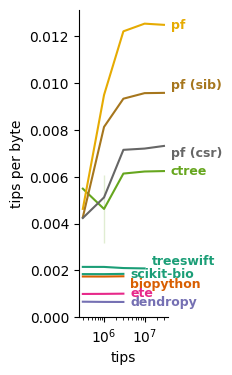

In [8]:
# 1. Extract the filtered data so we can easily reference it for labeling
plot_df = df[
    df["operation"].str.contains("bytes")
    & (df["library"] != "phyloframe")
    & (df["library"] != "phyloframe (in-memory)")
    & (df["n_leaves"] > 100_000)
].copy()
plot_df["tips"] = plot_df["n_leaves"]
plot_df["tips per byte"] = df["throughput"]
print(plot_df.describe())

unique_libs = plot_df["library"].unique()
palette = sns.color_palette("Dark2", n_colors=len(unique_libs))
with tp.teed(
    sns.relplot,
    data=plot_df,
    x="tips",
    y="tips per byte",
    hue="library",
    col="operation",
    col_order=[
        "memory_bytes",
    ],
    col_wrap=3,
    facet_kws={
        "sharex": False,
        "sharey": False,
    },
    kind="line",
    legend=False,
    palette=palette,
    teeplot_subdir=teeplot_subdir,
) as teed:

    # 2. Map colors to libraries so the text labels match the line colors
    color_dict = dict(zip(unique_libs, palette))

    # 3. Define a labeling function to map over each facet
    def label_line_ends(data, **kwargs):
        ax = plt.gca()
        maxmax = 0
        for library, group_df in (
            data.dropna(subset="tips per byte").groupby("library")
        ):
            if group_df.empty:
                continue

            # Find the coordinates for the largest x value (n_leaves)
            max_x_idx = group_df["tips"].idxmax()
            max_x = group_df.loc[max_x_idx, "tips"]
            max_y = group_df.loc[max_x_idx, "tips per byte"]
            maxmax = max(maxmax, max_y)

        for library, group_df in (
            data.dropna(subset="tips per byte").groupby("library")
        ):
            if group_df.empty:
                continue

            # Find the coordinates for the largest x value (n_leaves)
            max_x_idx = group_df["tips"].idxmax()
            max_x = group_df.loc[max_x_idx, "tips"]
            max_y = group_df.loc[max_x_idx, "tips per byte"]
            # if max_y < maxmax / 2.5:
            #     continue

            # Place the text at the end of the line
            ax.annotate(
                (
                    library
                    .replace("streaming+i32+", "")
                    .replace("streaming+i32", "")
                    .replace("()", "")
                    .replace(
                        "phyloframe (csr)", "\nphyloframe (csr)"
                    )
                    .replace(
                        "phyloframe (child/sib)", "phyloframe (sib)\n"
                    )
                    .replace("phyloframe", "pf")
                    .replace("compacttree", "ctree")
                    .replace("biopython", "\nbiopython")
                    .replace("treeswift", "treeswift\n")
                ),
                xy=(max_x, max_y),
                xytext=(5, 0), # Offset 5 points to the right
                textcoords="offset points",
                ha="left",
                va="center",
                color=color_dict.get(library, "black"),
                fontweight="bold",
                fontsize=9,
                clip_on=False,
            )

    # 4. Apply the function to the underlying FacetGrid
    teed.map_dataframe(label_line_ends)

    teed.fig.set_size_inches(5, 4)
    teed.fig.tight_layout()
    teed.set_titles(col_template="")
    teed.set(xscale="log")
    teed.set(ylim=(0, None))
